In [1]:
!pip install evaluate mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 92.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 86.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import mlflow
from datasets import load_dataset
import matplotlib.pyplot as plt
import string
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    DataCollatorWithPadding,
    Trainer,
    EarlyStoppingCallback
)
import evaluate
import numpy as np

In [3]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('humaid_classification')

2026/09/30 10:26:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/30 10:26:34 INFO mlflow.store.db.utils: Updating database tables
2026/09/30 10:26:36 INFO mlflow.tracking.fluent: Experiment with name 'humaid_classification' does not exist. Creating a new experiment.


<Experiment: artifact_location='/kaggle/working/mlruns/1', creation_time=1790763996599, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790763996599, lifecycle_stage='active', name='humaid_classification', tags={}, trace_location=None, workspace='default'>

In [4]:
ds = load_dataset('AijazAli7/humaid-ner')
ds

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/4.33M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/664k [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53531 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7788 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15159 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['record_id', 'text', 'humanitarian_category', 'entities', 'entity_count'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['record_id', 'text', 'humanitarian_category', 'entities', 'entity_count'],
        num_rows: 7788
    })
    test: Dataset({
        features: ['record_id', 'text', 'humanitarian_category', 'entities', 'entity_count'],
        num_rows: 15159
    })
})

In [5]:
classification_ds = ds.remove_columns(['record_id', 'entities', 'entity_count'])
classification_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'humanitarian_category'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['text', 'humanitarian_category'],
        num_rows: 7788
    })
    test: Dataset({
        features: ['text', 'humanitarian_category'],
        num_rows: 15159
    })
})

In [6]:
classification_ds['train'][0]

{'text': 'Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un',
 'humanitarian_category': 'injured_or_dead_people'}

<BarContainer object of 10 artists>

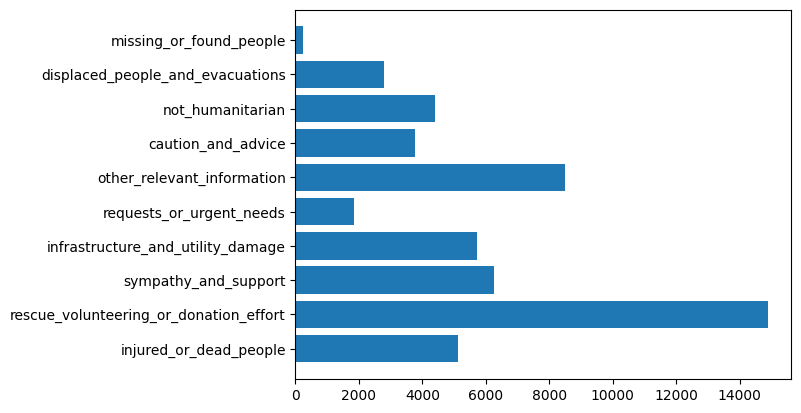

In [7]:
labels_count = {}

for label in classification_ds['train']['humanitarian_category']:
    if label not in labels_count:
        labels_count[label] = 1
    else:
        labels_count[label] += 1

plt.barh(labels_count.keys(), labels_count.values())

By the above chart we can see that this dataset is imbalanced

In [8]:
def remove_punkt(example):
    punkts = string.punctuation
    cleaned_texts = ['' for i in range(len(example['text']))]
    
    for i in range(len(example['text'])):
        for char in example['text'][i]:
            if char not in punkts:
                cleaned_texts[i] += char

    return {'text': cleaned_texts}

In [9]:
no_punkts_ds = classification_ds.map(remove_punkt, batched=True)
no_punkts_ds['train']['text'][0]

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7788 [00:00<?, ? examples/s]

Map:   0%|          | 0/15159 [00:00<?, ? examples/s]

'Powerful Ecuador quake kills at least 235 PORTOVIEJO  Rescuers in Ecuador raced to dig out people trapped un'

In [10]:
model_name = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(classification_ds['train'].unique('humanitarian_category')),
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased-finetuned-sst-2-english
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [11]:
def tokenize(example):
    return tokenizer(example['text'], truncation=True)

In [12]:
tokenized_ds = no_punkts_ds.map(tokenize, batched=True)
tokenized_ds

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7788 [00:00<?, ? examples/s]

Map:   0%|          | 0/15159 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'humanitarian_category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['text', 'humanitarian_category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7788
    })
    test: Dataset({
        features: ['text', 'humanitarian_category', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15159
    })
})

In [13]:
label2id = {label: idx for idx, label in enumerate(tokenized_ds['train'].unique('humanitarian_category'))}

In [14]:
def map_label_to_id(example):
    return {'labels': [label2id[label] for label in example['labels']]}

In [15]:
cleaned_ds = tokenized_ds.remove_columns(['text'])
cleaned_ds = cleaned_ds.rename_column('humanitarian_category', 'labels')
cleaned_ds = cleaned_ds.map(map_label_to_id, batched=True)
cleaned_ds

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7788 [00:00<?, ? examples/s]

Map:   0%|          | 0/15159 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7788
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15159
    })
})

In [16]:
training_args = TrainingArguments(
    output_dir='baseline',
    eval_strategy='steps',
    eval_steps=125,
    bf16=True,
    bf16_full_eval=True,
    per_device_train_batch_size=32,
    logging_strategy='steps',
    logging_steps=125,
    save_strategy='best',
    save_steps=125,
    report_to='mlflow',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    num_train_epochs=3
)

In [17]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
def compute_metrics(eval_prediction):
    accuracy = evaluate.load('accuracy')
    prec_rec_f1 = evaluate.combine(['precision', 'recall', 'f1'])

    logits, labels = eval_prediction
    preds = np.argmax(logits, axis=1)

    metrics = accuracy.compute(predictions=preds, references=labels)
    metrics.update(prec_rec_f1.compute(predictions=preds, references=labels, average='macro'))
    
    return metrics

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=cleaned_ds['train'],
    eval_dataset=cleaned_ds['validation'],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [20]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
125,2.466108,1.645650,0.726117,0.683812,0.584825,0.598337
250,1.547292,1.483893,0.750770,0.741164,0.717529,0.724977
375,1.409775,1.413746,0.756035,0.740094,0.718029,0.720869
500,1.391198,1.332251,0.762327,0.747348,0.732030,0.737199
625,1.357145,1.317269,0.763097,0.729163,0.741765,0.731560
750,1.343795,1.308990,0.770544,0.758914,0.743171,0.746910
875,1.240330,1.261608,0.774140,0.749081,0.758655,0.752486
1000,1.082080,1.294923,0.770673,0.767315,0.741022,0.750709
1125,1.075157,1.280106,0.773112,0.749566,0.757800,0.752631
1250,1.031870,1.287393,0.770031,0.749614,0.750954,0.748426


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=1250, training_loss=1.3944751708984375, metrics={'train_runtime': 483.8753, 'train_samples_per_second': 331.889, 'train_steps_per_second': 5.189, 'total_flos': 1311672567757500.0, 'train_loss': 1.3944751708984375, 'epoch': 1.4934289127837514})